# Validação offline da rede de quatro neurônios

Este notebook exercita a rede descrita no artigo sem Webots. Ele verifica a dinâmica neural, a causalidade da maraca, a evolução dos pesos e o critério de cinco movimentos consecutivos.

> **Limite:** o ambiente abaixo é uma aproximação matemática deliberadamente simples. Ele não valida torque, atrito, contato, geometria ou o sentido físico dos motores. Esses aspectos continuam pertencendo ao Webots.

## 1. Configuração reprodutível

A rede usa somente a biblioteca padrão. NumPy e Matplotlib aparecem aqui apenas para análise e visualização.

In [2]:
# Permite executar o notebook com o kernel iniciado na raiz ou em notebooks/.
from pathlib import Path
import sys

search_start = Path.cwd().resolve()
project_root = next(
    (candidate for candidate in (search_start, *search_start.parents)
     if (candidate / 'src' / '__init__.py').is_file()),
    None,
)
if project_root is None:
    raise RuntimeError('Raiz do projeto não encontrada a partir do diretório atual.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Raiz do projeto: {project_root}')

Raiz do projeto: C:\Users\lenin\Projects\ufabc\ufabc-DomanNeurocomputationalModel


In [3]:
from dataclasses import dataclass
import random

import matplotlib.pyplot as plt
import numpy as np

from src.experiments import ExperimentConfig, ExperimentRunner, MovementDirection
from src.neural import FourNeuronNetwork, MotorAction, NeuralConfig

SEED = 42
MAX_ITERATIONS = 80

neural_config = NeuralConfig(random_seed=SEED)
experiment_config = ExperimentConfig(
    movement_duration_seconds=0.5,
    stationary_threshold=0.005,
    sound_intensity=1.0,
    downhill_sign=-1,
    learning_streak=5,
)

neural_config, experiment_config

(NeuralConfig(neuron_count=4, recurrent_weight=0.7, sigmoid_gain=25.0, synaptic_learning_rate=0.01, intrinsic_learning_rate=0.01, initial_shift=0.5, initial_weight_min=0.1, initial_weight_max=0.9, competition_mode=<CompetitionMode.DETERMINISTIC: 'deterministic'>, plasticity_scope=<PlasticityScope.WINNER_ONLY: 'winner_only'>, intrinsic_output_source=<IntrinsicOutputSource.POST_COMPETITION: 'post_competition'>, activation_noise_std=0.0, random_seed=42, optional_weight_bounds=None, sensory_normalization=SensoryNormalization(acceleration_offset=0.0, acceleration_scale=1.0, visual_offset=0.0, visual_scale=1.0, sound_offset=0.0, sound_scale=1.0)),
 ExperimentConfig(movement_duration_seconds=0.5, stationary_threshold=0.005, sound_intensity=1.0, downhill_sign=-1, learning_streak=5))

## 2. Plano inclinado simplificado

Cada ação possui um efeito médio hipotético. Deslocamento negativo representa descida. A gravidade adiciona uma pequena tendência descendente e uma seed controla o ruído. A aceleração é mais intensa quando o movimento resultante é descendente. Todos esses números são hipóteses do notebook, não parâmetros publicados no artigo.

In [4]:
@dataclass(frozen=True)
class ToyObservation:
    displacement: float
    acceleration: float
    visual: float


class ToyInclinedPlane:
    ACTION_EFFECT = {
        MotorAction.FRONT_CLOCKWISE: -0.010,
        MotorAction.FRONT_COUNTERCLOCKWISE: 0.008,
        MotorAction.REAR_CLOCKWISE: -0.012,
        MotorAction.REAR_COUNTERCLOCKWISE: 0.009,
    }

    def __init__(self, seed: int, gravity_effect: float = -0.002, noise_std: float = 0.0015):
        self.rng = random.Random(seed)
        self.gravity_effect = gravity_effect
        self.noise_std = noise_std

    def execute(self, action: MotorAction) -> ToyObservation:
        displacement = (
            self.ACTION_EFFECT[action]
            + self.gravity_effect
            + self.rng.gauss(0.0, self.noise_std)
        )
        acceleration = max(0.0, -displacement * 20.0)
        visual = max(0.0, -displacement * 10.0)
        return ToyObservation(displacement, acceleration, visual)


ToyInclinedPlane.ACTION_EFFECT

{<MotorAction.FRONT_CLOCKWISE: 0>: -0.01,
 <MotorAction.FRONT_COUNTERCLOCKWISE: 1>: 0.008,
 <MotorAction.REAR_CLOCKWISE: 2>: -0.012,
 <MotorAction.REAR_COUNTERCLOCKWISE: 3>: 0.009}

## 3. Uma execução completa

A ação pendente é executada no ambiente. Somente depois o deslocamento é classificado, a maraca é gerada e a rede escolhe a próxima ação.

In [5]:
def run_trial(seed: int, max_iterations: int = MAX_ITERATIONS, sound_intensity: float = 1.0):
    network = FourNeuronNetwork(NeuralConfig(random_seed=seed))
    runner = ExperimentRunner(
        network,
        ExperimentConfig(
            movement_duration_seconds=experiment_config.movement_duration_seconds,
            stationary_threshold=experiment_config.stationary_threshold,
            sound_intensity=sound_intensity,
            downhill_sign=experiment_config.downhill_sign,
            learning_streak=experiment_config.learning_streak,
        ),
    )
    environment = ToyInclinedPlane(seed=seed + 10_000)
    runner.start()
    history = []

    for _ in range(max_iterations):
        observation = environment.execute(runner.pending_action)
        result = runner.complete_iteration(
            displacement=observation.displacement,
            acceleration=observation.acceleration,
            visual=observation.visual,
        )
        history.append(result)
        if result.learning.downward_criterion_reached:
            break

    return history


history = run_trial(SEED)
last = history[-1]
print(f'Iterações: {len(history)}')
print(f'Critério literal: {last.learning.paper_criterion_reached}')
print(f'Cinco descidas: {last.learning.downward_criterion_reached}')
print(f'Última ação: {last.next_action.name}')

Iterações: 41
Critério literal: True
Cinco descidas: True
Última ação: REAR_COUNTERCLOCKWISE


In [6]:
print('Primeiras iterações:')
for result in history[:10]:
    print(
        f'{result.iteration:02d}  '
        f'{result.previous_action.name:28s}  '
        f'{result.direction.value:10s}  '
        f'maraca={str(result.rewarding_sound):5s}  '
        f'deslocamento={result.displacement:+.4f} m'
    )

Primeiras iterações:
00  FRONT_CLOCKWISE               DOWN        maraca=True   deslocamento=-0.0129 m
01  REAR_CLOCKWISE                DOWN        maraca=True   deslocamento=-0.0129 m
02  REAR_COUNTERCLOCKWISE         UP          maraca=False  deslocamento=+0.0071 m
03  REAR_COUNTERCLOCKWISE         UP          maraca=False  deslocamento=+0.0112 m
04  REAR_COUNTERCLOCKWISE         UP          maraca=False  deslocamento=+0.0063 m
05  REAR_COUNTERCLOCKWISE         UP          maraca=False  deslocamento=+0.0062 m
06  REAR_COUNTERCLOCKWISE         STATIONARY  maraca=False  deslocamento=+0.0050 m
07  REAR_COUNTERCLOCKWISE         UP          maraca=False  deslocamento=+0.0057 m
08  REAR_COUNTERCLOCKWISE         STATIONARY  maraca=False  deslocamento=+0.0049 m
09  FRONT_COUNTERCLOCKWISE        UP          maraca=False  deslocamento=+0.0059 m


## 4. Evolução das ações e dos sinais

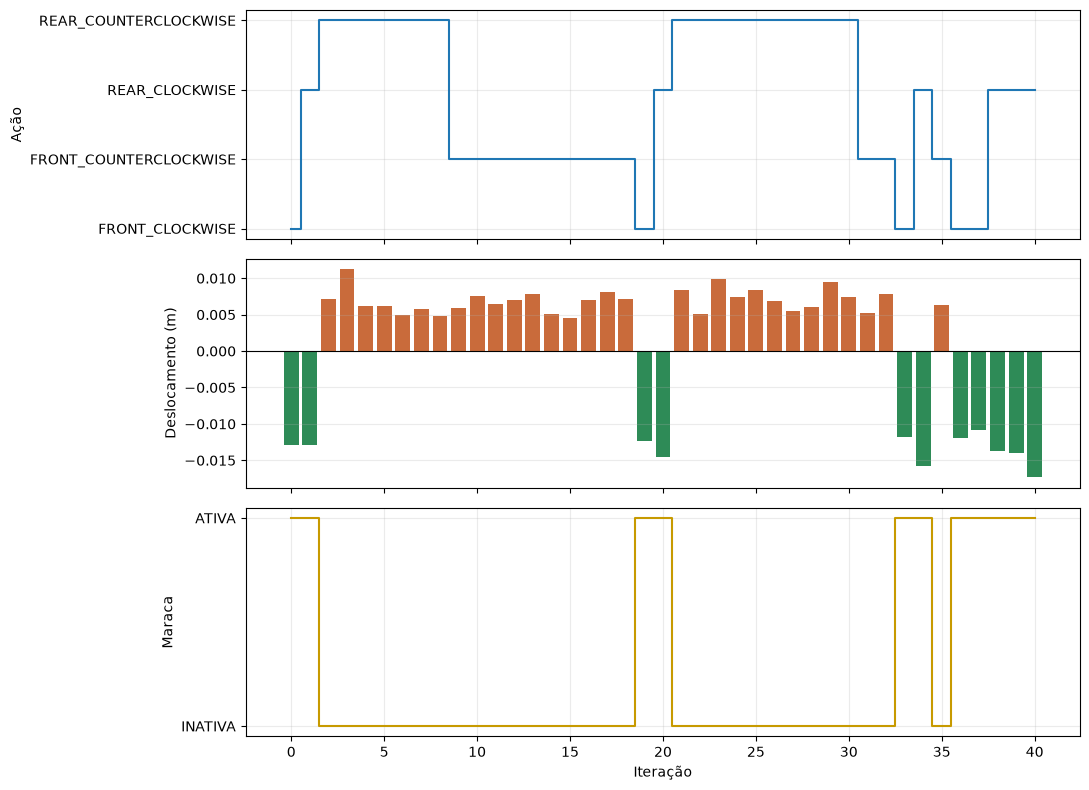

In [7]:
iterations = np.array([item.iteration for item in history])
actions = np.array([item.previous_action.value for item in history])
displacements = np.array([item.displacement for item in history])
sounds = np.array([item.rewarding_sound for item in history], dtype=int)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].step(iterations, actions, where='mid')
axes[0].set_yticks(range(4), [action.name for action in MotorAction])
axes[0].set_ylabel('Ação')
axes[0].grid(alpha=0.25)

axes[1].bar(iterations, displacements, color=np.where(displacements < 0, '#2e8b57', '#c96b3b'))
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Deslocamento (m)')
axes[1].grid(axis='y', alpha=0.25)

axes[2].step(iterations, sounds, where='mid', color='#c79a00')
axes[2].set_yticks([0, 1], ['INATIVA', 'ATIVA'])
axes[2].set_ylabel('Maraca')
axes[2].set_xlabel('Iteração')
axes[2].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Plasticidade sináptica e intrínseca

As conexões diagonais são omitidas do gráfico de pesos porque permanecem fixas em `0.7`.

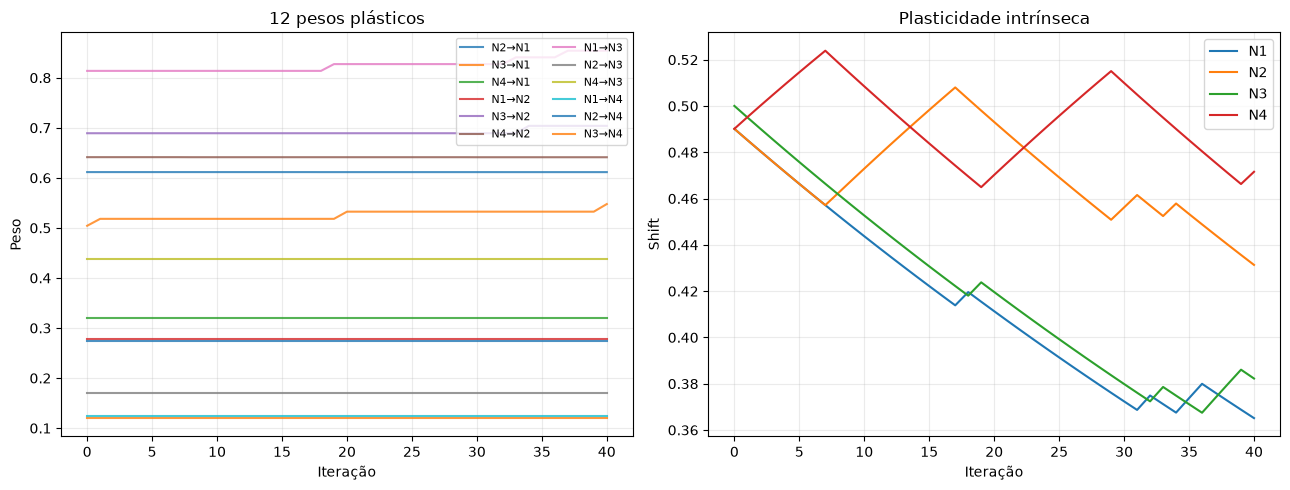

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(4):
    for j in range(4):
        if i != j:
            values = [item.neural_step.weights_after[i][j] for item in history]
            axes[0].plot(iterations, values, label=f'N{j + 1}→N{i + 1}', alpha=0.8)
axes[0].set_title('12 pesos plásticos')
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Peso')
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=2, fontsize=8)

for i in range(4):
    values = [item.neural_step.shifts_after[i] for item in history]
    axes[1].plot(iterations, values, label=f'N{i + 1}')
axes[1].set_title('Plasticidade intrínseca')
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Shift')
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
plt.show()

## 6. Comparação entre seeds

Esta análise verifica reprodutibilidade e variabilidade. Ela não pretende reproduzir ainda os valores da Tabela 1 do artigo, porque o ambiente físico e a normalização sensorial continuam hipotéticos.

Sucessos: 23/30
Média de iterações: 17.13
Desvio padrão: 16.46


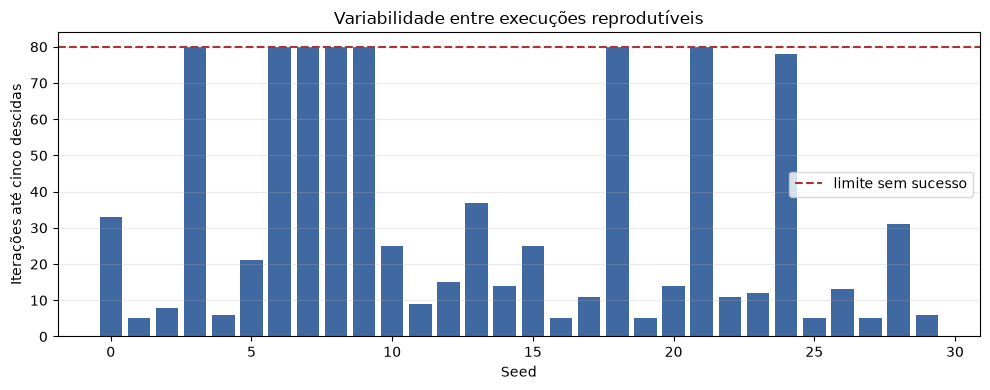

In [9]:
seeds = range(30)
iterations_to_downward = []
successes = []

for seed in seeds:
    trial = run_trial(seed)
    success = trial[-1].learning.downward_criterion_reached
    successes.append(success)
    iterations_to_downward.append(len(trial) if success else np.nan)

successful_values = np.array([value for value in iterations_to_downward if not np.isnan(value)])
print(f'Sucessos: {sum(successes)}/{len(successes)}')
if successful_values.size:
    print(f'Média de iterações: {successful_values.mean():.2f}')
    print(f'Desvio padrão: {successful_values.std(ddof=1):.2f}')

plt.figure(figsize=(10, 4))
plt.bar(list(seeds), np.nan_to_num(iterations_to_downward, nan=MAX_ITERATIONS), color='#4169a1')
plt.axhline(MAX_ITERATIONS, color='#a33', linestyle='--', label='limite sem sucesso')
plt.xlabel('Seed')
plt.ylabel('Iterações até cinco descidas')
plt.title('Variabilidade entre execuções reprodutíveis')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()